Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 59.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.74MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.96MB/s]


Training images: 60000
Testing images : 10000
Batch size     : 64

Calculating MNIST pixel statistics...


RBM MODEL SUMMARY
RBM()

Visible units    : 784
Hidden units     : 128
Input image      : 28 x 28
Input features   : 784
Hidden features  : 128
Weight matrix    : (784, 128)
Visible bias     : (784,)
Hidden bias      : (128,)
Total parameters : 101264


TRAINING SETTINGS
Epochs        : 10
Learning rate : 0.01
Batch size    : 64
Training      : Persistent Contrastive Divergence


RBM TRAINING
Epoch [01/10] Loss: 0.074807
Epoch [02/10] Loss: 0.089765
Epoch [03/10] Loss: 0.095258
Epoch [04/10] Loss: 0.098810
Epoch [05/10] Loss: 0.101355
Epoch [06/10] Loss: 0.103284
Epoch [07/10] Loss: 0.104968
Epoch [08/10] Loss: 0.106434
Epoch [09/10] Loss: 0.107644
Epoch [10/10] Loss: 0.108344


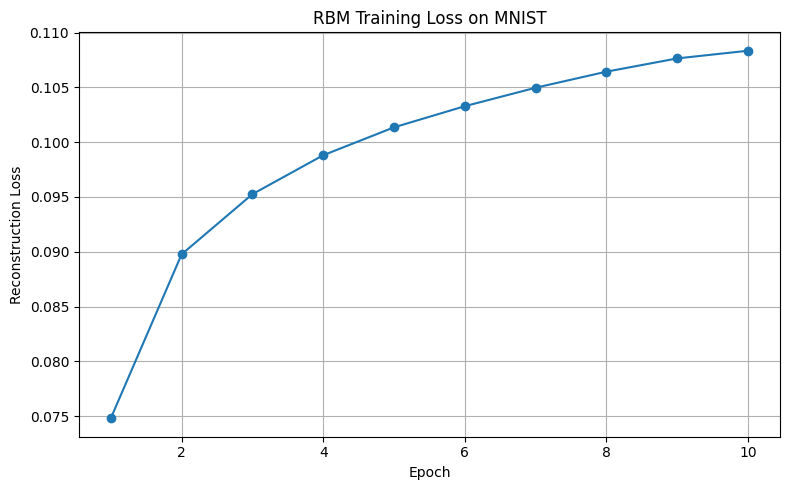



GENERATING NEW HANDWRITTEN DIGITS


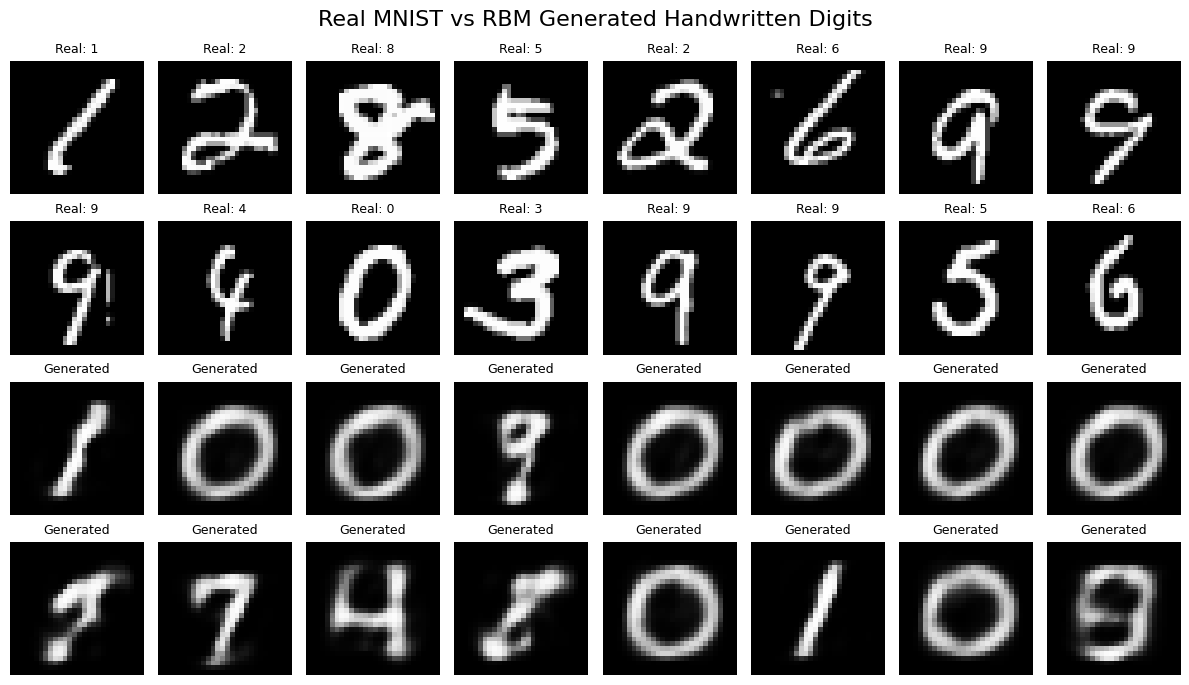



FINAL RESULT
MNIST dataset loaded successfully
Real images loaded
RBM model created
RBM model summary displayed
Persistent Contrastive Divergence used
Training epochs: 10
Training loss displayed
New handwritten images generated
Real + Generated images displayed in one grid

RBM MNIST program completed successfully.


In [ ]:
# Q1. Generate an image by using Restricted Boltzmann Machine using a real image dataset (Use MNIST dataset). Use the DataLoader class of the torch.utils.data library to load training and testing datasets, set the batch size to 64 and apply the transformations. Visualize the real and generated image.

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt



torch.manual_seed(42)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


transform = transforms.Compose([
    transforms.ToTensor()
])


train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("Training images:", len(train_dataset))
print("Testing images :", len(test_dataset))
print("Batch size     :", BATCH_SIZE)



real_images, real_labels = next(iter(train_loader))



class RBM(nn.Module):

    def __init__(
        self,
        visible_units=784,
        hidden_units=128,
        initial_visible_bias=None
    ):

        super().__init__()

        self.visible_units = visible_units
        self.hidden_units = hidden_units


        self.W = nn.Parameter(
            torch.randn(
                visible_units,
                hidden_units,
                device=device
            ) * 0.01
        )


        if initial_visible_bias is not None:

            self.visible_bias = nn.Parameter(
                initial_visible_bias.clone()
            )

        else:

            self.visible_bias = nn.Parameter(
                torch.zeros(
                    visible_units,
                    device=device
                )
            )


        self.hidden_bias = nn.Parameter(
            torch.zeros(
                hidden_units,
                device=device
            )
        )



    def hidden_probability(self, visible):

        return torch.sigmoid(
            torch.matmul(
                visible,
                self.W
            )
            + self.hidden_bias
        )



    def visible_probability(self, hidden):

        return torch.sigmoid(
            torch.matmul(
                hidden,
                self.W.t()
            )
            + self.visible_bias
        )



    def sample_hidden(self, visible):

        probability = self.hidden_probability(
            visible
        )

        sample = torch.bernoulli(
            probability
        )

        return probability, sample



    def sample_visible(self, hidden):

        probability = self.visible_probability(
            hidden
        )

        sample = torch.bernoulli(
            probability
        )

        return probability, sample




pixel_sum = torch.zeros(
    784,
    device=device
)

total_images = 0

print("\nCalculating MNIST pixel statistics...")


for batch_images, _ in train_loader:

    batch = batch_images.view(
        batch_images.size(0),
        -1
    ).to(device)

    pixel_sum += batch.sum(dim=0)

    total_images += batch.size(0)


pixel_mean = (
    pixel_sum / total_images
)



pixel_mean = torch.clamp(
    pixel_mean,
    min=0.01,
    max=0.99
)



initial_visible_bias = torch.log(
    pixel_mean / (1 - pixel_mean)
)



VISIBLE_UNITS = 784
HIDDEN_UNITS = 128


rbm = RBM(
    visible_units=VISIBLE_UNITS,
    hidden_units=HIDDEN_UNITS,
    initial_visible_bias=initial_visible_bias
).to(device)



total_parameters = sum(
    p.numel()
    for p in rbm.parameters()
)


print("\n")
print("=" * 60)
print("RBM MODEL SUMMARY")
print("=" * 60)

print(rbm)

print("\nVisible units    :", VISIBLE_UNITS)
print("Hidden units     :", HIDDEN_UNITS)
print("Input image      : 28 x 28")
print("Input features   : 784")
print("Hidden features  :", HIDDEN_UNITS)
print("Weight matrix    :", tuple(rbm.W.shape))
print("Visible bias     :", tuple(rbm.visible_bias.shape))
print("Hidden bias      :", tuple(rbm.hidden_bias.shape))
print("Total parameters :", total_parameters)



EPOCHS = 10
LEARNING_RATE = 0.01

loss_history = []


print("\n")
print("=" * 60)
print("TRAINING SETTINGS")
print("=" * 60)

print("Epochs        :", EPOCHS)
print("Learning rate :", LEARNING_RATE)
print("Batch size    :", BATCH_SIZE)
print("Training      : Persistent Contrastive Divergence")




persistent_visible = None

rbm.train()


print("\n")
print("=" * 60)
print("RBM TRAINING")
print("=" * 60)


for epoch in range(EPOCHS):

    total_loss = 0.0


    for batch_images, _ in train_loader:



        v0 = batch_images.view(
            batch_images.size(0),
            -1
        ).to(device)



        positive_hidden_probability = (
            rbm.hidden_probability(v0)
        )



        if persistent_visible is None:

            persistent_visible = torch.bernoulli(
                torch.rand_like(v0)
            )



        negative_hidden_probability = (
            rbm.hidden_probability(
                persistent_visible
            )
        )


        negative_hidden_sample = torch.bernoulli(
            negative_hidden_probability
        )


        negative_visible_probability = (
            rbm.visible_probability(
                negative_hidden_sample
            )
        )


        negative_visible = torch.bernoulli(
            negative_visible_probability
        )



        persistent_visible = (
            negative_visible.detach()
        )



        reconstruction_loss = torch.mean(
            (
                v0
                - negative_visible_probability
            ) ** 2
        )



        batch_size = v0.size(0)


        with torch.no_grad():

            positive_association = torch.matmul(
                v0.t(),
                positive_hidden_probability
            )


            negative_association = torch.matmul(
                negative_visible.t(),
                negative_hidden_probability
            )


            rbm.W += LEARNING_RATE * (
                positive_association
                - negative_association
            ) / batch_size


            rbm.visible_bias += LEARNING_RATE * (
                v0
                - negative_visible
            ).mean(dim=0)


            rbm.hidden_bias += LEARNING_RATE * (
                positive_hidden_probability
                - negative_hidden_probability
            ).mean(dim=0)


        total_loss += reconstruction_loss.item()


    average_loss = (
        total_loss / len(train_loader)
    )


    loss_history.append(
        average_loss
    )


    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
        f"Loss: {average_loss:.6f}"
    )



plt.figure(figsize=(8, 5))


plt.plot(
    range(1, EPOCHS + 1),
    loss_history,
    marker="o"
)


plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")


plt.title(
    "RBM Training Loss on MNIST"
)


plt.grid(True)

plt.tight_layout()

plt.show()



print("\n")
print("=" * 60)
print("GENERATING NEW HANDWRITTEN DIGITS")
print("=" * 60)


rbm.eval()


NUMBER_OF_IMAGES = 16
GIBBS_STEPS = 1500


with torch.no_grad():


    generated = torch.bernoulli(
        torch.rand(
            NUMBER_OF_IMAGES,
            VISIBLE_UNITS,
            device=device
        )
    )



    for step in range(GIBBS_STEPS):



        hidden_probability = (
            rbm.hidden_probability(
                generated
            )
        )


        hidden_sample = torch.bernoulli(
            hidden_probability
        )



        visible_probability = (
            rbm.visible_probability(
                hidden_sample
            )
        )



        generated = torch.bernoulli(
            visible_probability
        )



    generated_probability = (
        rbm.visible_probability(
            torch.bernoulli(
                rbm.hidden_probability(
                    generated
                )
            )
        )
    )


    generated_images = (
        generated_probability
        .view(
            NUMBER_OF_IMAGES,
            28,
            28
        )
        .cpu()
    )



plt.figure(figsize=(12, 7))



for i in range(16):

    plt.subplot(4, 8, i + 1)

    plt.imshow(
        real_images[i].squeeze(),
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        "Real: " + str(
            real_labels[i].item()
        ),
        fontsize=9
    )

    plt.axis("off")



for i in range(16):

    plt.subplot(4, 8, i + 17)

    plt.imshow(
        generated_images[i],
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        "Generated",
        fontsize=9
    )

    plt.axis("off")


plt.suptitle(
    "Real MNIST vs RBM Generated Handwritten Digits",
    fontsize=16
)


plt.tight_layout()

plt.show()



print("\n")
print("=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("MNIST dataset loaded successfully")
print("Real images loaded")
print("RBM model created")
print("RBM model summary displayed")
print("Persistent Contrastive Divergence used")
print("Training epochs:", EPOCHS)
print("Training loss displayed")
print("New handwritten images generated")
print("Real + Generated images displayed in one grid")

print("\nRBM MNIST program completed successfully.")

STEP 1: COLLABORATION DATASET
[[1. 1. 0. 1. 0.]
 [1. 0. 1. 1. 0.]
 [0. 1. 1. 0. 1.]
 [1. 1. 1. 0. 0.]
 [0. 1. 0. 1. 1.]
 [1. 0. 1. 0. 1.]]


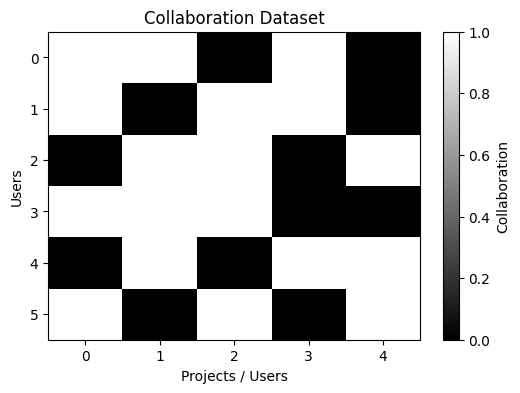


STEP 2: RBM MODEL
RBM()

Visible Units: 5
Hidden Units : 3

STEP 3: RBM TRAINING
Epoch  20/100    Loss = 0.2406
Epoch  40/100    Loss = 0.2421
Epoch  60/100    Loss = 0.2344
Epoch  80/100    Loss = 0.2368
Epoch 100/100    Loss = 0.2355

STEP 4: TRAINING LOSS
Training completed successfully.


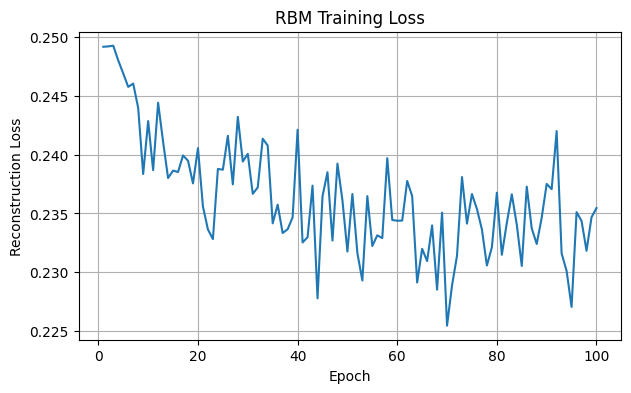


STEP 5: PREDICTED COLLABORATION
[[1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]
 [1. 1. 1. 0. 0.]]

STEP 6: COLLABORATION PROBABILITY
[[0.68 0.68 0.69 0.5  0.47]
 [0.68 0.68 0.69 0.5  0.47]
 [0.67 0.68 0.69 0.5  0.47]
 [0.68 0.68 0.69 0.5  0.47]
 [0.67 0.67 0.68 0.5  0.48]
 [0.68 0.68 0.69 0.5  0.47]]


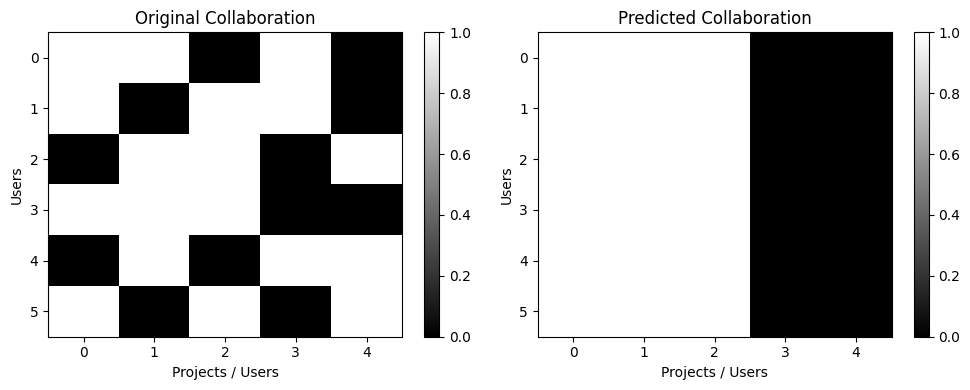


FINAL RESULT
RBM successfully learned the collaboration patterns.
Collaboration prediction completed successfully.


In [ ]:
# Q2. Write a python program to design a Restricted Boltzmann Machine for predicting collaboration.

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


data = np.array([
    [1, 1, 0, 1, 0],
    [1, 0, 1, 1, 0],
    [0, 1, 1, 0, 1],
    [1, 1, 1, 0, 0],
    [0, 1, 0, 1, 1],
    [1, 0, 1, 0, 1]
], dtype=np.float32)

data = torch.tensor(data)

print("=" * 55)
print("STEP 1: COLLABORATION DATASET")
print("=" * 55)
print(data.numpy())



plt.figure(figsize=(6, 4))

plt.imshow(data.numpy(), cmap="gray", aspect="auto")

plt.title("Collaboration Dataset")
plt.xlabel("Projects / Users")
plt.ylabel("Users")

plt.colorbar(label="Collaboration")

plt.show()



class RBM(nn.Module):

    def __init__(self, visible_units, hidden_units):

        super().__init__()

        self.W = nn.Parameter(
            torch.randn(visible_units, hidden_units) * 0.01
        )

        self.visible_bias = nn.Parameter(
            torch.zeros(visible_units)
        )

        self.hidden_bias = nn.Parameter(
            torch.zeros(hidden_units)
        )

    def hidden_probability(self, visible):

        return torch.sigmoid(
            torch.matmul(visible, self.W)
            + self.hidden_bias
        )

    def visible_probability(self, hidden):

        return torch.sigmoid(
            torch.matmul(hidden, self.W.t())
            + self.visible_bias
        )

    def gibbs_sampling(self, visible):

        hidden_prob = self.hidden_probability(visible)

        hidden = torch.bernoulli(hidden_prob)

        visible_prob = self.visible_probability(hidden)

        visible = torch.bernoulli(visible_prob)

        return visible_prob, visible



visible_units = 5
hidden_units = 3

rbm = RBM(
    visible_units,
    hidden_units
)

print("\n" + "=" * 55)
print("STEP 2: RBM MODEL")
print("=" * 55)

print(rbm)

print("\nVisible Units:", visible_units)
print("Hidden Units :", hidden_units)



epochs = 100
learning_rate = 0.05

losses = []

print("\n" + "=" * 55)
print("STEP 3: RBM TRAINING")
print("=" * 55)

for epoch in range(epochs):


    hidden_prob = rbm.hidden_probability(data)

    hidden = torch.bernoulli(hidden_prob)


    reconstructed_prob = rbm.visible_probability(hidden)

    reconstructed = torch.bernoulli(
        reconstructed_prob
    )

    hidden_reconstructed_prob = rbm.hidden_probability(
        reconstructed
    )


    positive = torch.matmul(
        data.t(),
        hidden_prob
    )

    negative = torch.matmul(
        reconstructed.t(),
        hidden_reconstructed_prob
    )

    batch_size = data.shape[0]

    rbm.W.data += learning_rate * (
        positive - negative
    ) / batch_size


    rbm.visible_bias.data += learning_rate * torch.mean(
        data - reconstructed,
        dim=0
    )


    rbm.hidden_bias.data += learning_rate * torch.mean(
        hidden_prob - hidden_reconstructed_prob,
        dim=0
    )


    loss = torch.mean(
        (data - reconstructed_prob) ** 2
    )

    losses.append(loss.item())


    if (epoch + 1) % 20 == 0:

        print(
            f"Epoch {epoch + 1:3d}/{epochs} "
            f"   Loss = {loss.item():.4f}"
        )



print("\n" + "=" * 55)
print("STEP 4: TRAINING LOSS")
print("=" * 55)

print("Training completed successfully.")

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, epochs + 1),
    losses
)

plt.title("RBM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")

plt.grid()

plt.show()



hidden_prob = rbm.hidden_probability(data)

predicted_probability = rbm.visible_probability(
    hidden_prob
)


predicted = (
    predicted_probability >= 0.5
).float()


print("\n" + "=" * 55)
print("STEP 5: PREDICTED COLLABORATION")
print("=" * 55)

print(predicted.numpy())



print("\n" + "=" * 55)
print("STEP 6: COLLABORATION PROBABILITY")
print("=" * 55)

print(
    np.round(
        predicted_probability.detach().numpy(),
        2
    )
)



plt.figure(figsize=(10, 4))


plt.subplot(1, 2, 1)

plt.imshow(
    data.numpy(),
    cmap="gray",
    aspect="auto"
)

plt.title("Original Collaboration")
plt.xlabel("Projects / Users")
plt.ylabel("Users")

plt.colorbar()



plt.subplot(1, 2, 2)

plt.imshow(
    predicted.detach().numpy(),
    cmap="gray",
    aspect="auto"
)

plt.title("Predicted Collaboration")
plt.xlabel("Projects / Users")
plt.ylabel("Users")

plt.colorbar()

plt.tight_layout()

plt.show()



print("\n" + "=" * 55)
print("FINAL RESULT")
print("=" * 55)

print("RBM successfully learned the collaboration patterns.")
print("Collaboration prediction completed successfully.")

Device: cpu

Dataset Information
Training samples : 60000
Testing samples  : 10000
Batch size       : 64
Image size       : 28 x 28
Input features   : 784
Output classes   : 10


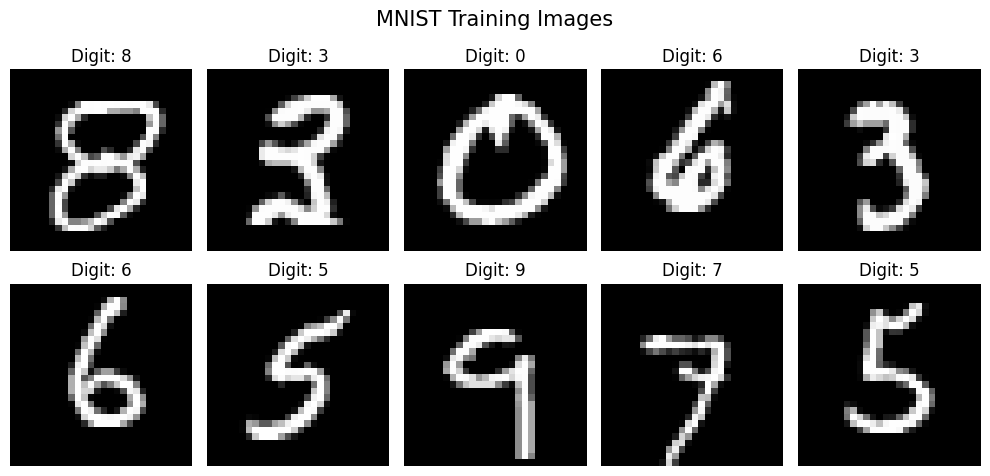



                 BERNOULLI DBN MODEL SUMMARY

Architecture:
----------------------------------------------------------------------
Input Layer        : 784 neurons
                     ↓
RBM Layer 1        : 256 hidden neurons
                     ↓
RBM Layer 2        : 128 hidden neurons
                     ↓
Classification     : 10 output classes
                     ↓
Output             : Digit 0 - 9


RBM 1
----------------------------------------------------------------------
Visible units      : 784
Hidden units       : 256
Weight matrix      : (784, 256)
Visible bias       : (784,)
Hidden bias        : (256,)
Total parameters   : 201744


RBM 2
----------------------------------------------------------------------
Visible units      : 256
Hidden units       : 128
Weight matrix      : (256, 128)
Visible bias       : (256,)
Hidden bias        : (128,)
Total parameters   : 33152


                 TRAINING RBM 1
Epoch 1/5 - Loss: 0.0553
Epoch 2/5 - Loss: 0.0367
Epoch 3/5 - Loss:

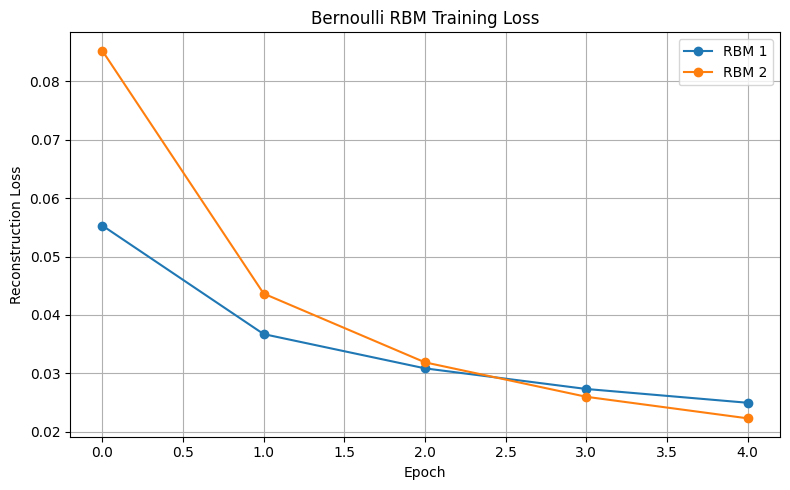



                 COMPLETE MODEL SUMMARY
DBNClassifier(
  (rbm1): RBM()
  (rbm2): RBM()
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)


Architecture
----------------------------------------------------------------------
Input Image       : 28 x 28
Flattened Input   : 784
RBM 1             : 784 → 256
RBM 2             : 256 → 128
Classifier        : 128 → 10
Output Classes    : 10
Classes           : 0, 1, 2, 3, 4, 5, 6, 7, 8, 9


Activation / Training
----------------------------------------------------------------------
RBM Activation    : Sigmoid
Sampling          : Bernoulli
RBM Training      : Contrastive Divergence
Classification    : Cross-Entropy Loss
Optimizer         : Adam


Parameters
----------------------------------------------------------------------
RBM 1 Parameters  : 201744
RBM 2 Parameters  : 33152
Total Parameters  : 236186


             END OF MODEL SUMMARY


              TRAINING DBN CLASSIFIER
Epoch 1/5 - Loss: 0.7223
Epoch 2/5 - Loss:

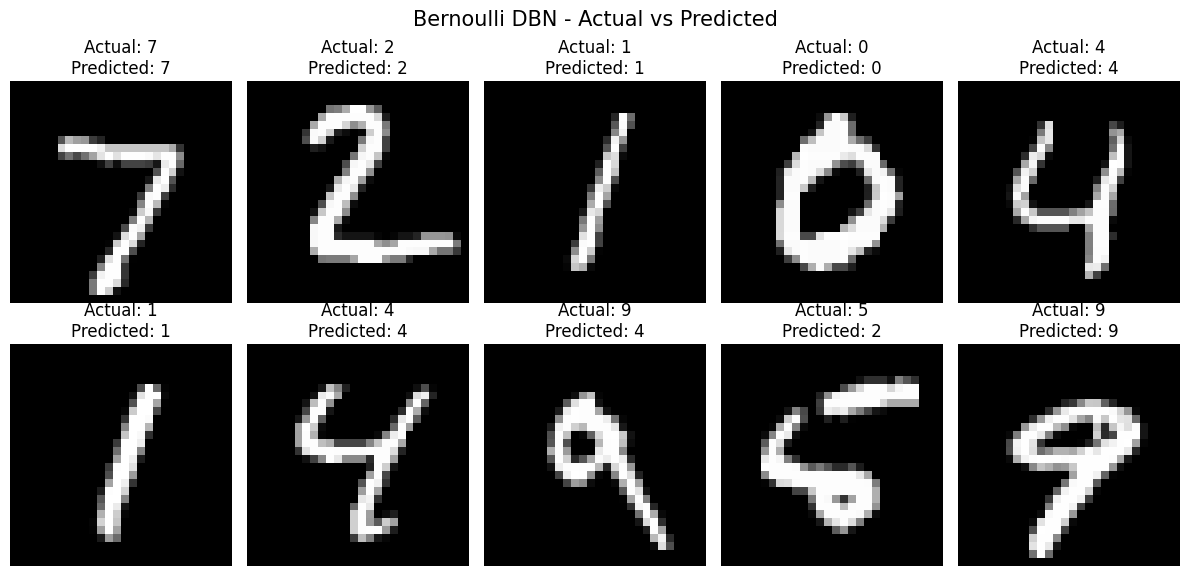



                    FINAL OUTPUT
✓ MNIST dataset loaded
✓ RBM 1 trained
✓ RBM 2 trained
✓ Bernoulli sampling used
✓ Contrastive Divergence used
✓ DBN classifier created
✓ Classification layer trained
✓ Test predictions generated
✓ Final Accuracy: 91.08%


Model Architecture:
784 → 256 → 128 → 10


Classification Classes:
0  1  2  3  4  5  6  7  8  9

Program completed successfully!


In [ ]:
# Q3. Implement Deep Belief network using Restricted RBM to create an effective stack of models to perform digit classification.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt



device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)



transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


print("\nDataset Information")
print("=" * 60)
print("Training samples :", len(train_dataset))
print("Testing samples  :", len(test_dataset))
print("Batch size       :", BATCH_SIZE)
print("Image size       : 28 x 28")
print("Input features   : 784")
print("Output classes   : 10")



images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 5))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"Digit: {labels[i].item()}"
    )

    plt.axis("off")

plt.suptitle(
    "MNIST Training Images",
    fontsize=15
)

plt.tight_layout()
plt.show()



class RBM(nn.Module):

    def __init__(
        self,
        visible_units,
        hidden_units
    ):

        super().__init__()

        self.W = nn.Parameter(
            torch.randn(
                visible_units,
                hidden_units
            ) * 0.01
        )

        self.visible_bias = nn.Parameter(
            torch.zeros(
                visible_units
            )
        )

        self.hidden_bias = nn.Parameter(
            torch.zeros(
                hidden_units
            )
        )



    def hidden_probability(self, v):

        return torch.sigmoid(
            torch.matmul(v, self.W)
            + self.hidden_bias
        )



    def visible_probability(self, h):

        return torch.sigmoid(
            torch.matmul(
                h,
                self.W.t()
            )
            + self.visible_bias
        )



    def sample_hidden(self, v):

        probability = (
            self.hidden_probability(v)
        )

        sample = torch.bernoulli(
            probability
        )

        return probability, sample



    def sample_visible(self, h):

        probability = (
            self.visible_probability(h)
        )

        sample = torch.bernoulli(
            probability
        )

        return probability, sample



rbm1 = RBM(
    784,
    256
).to(device)


rbm2 = RBM(
    256,
    128
).to(device)



print("\n")
print("=" * 70)
print("                 BERNOULLI DBN MODEL SUMMARY")
print("=" * 70)

print("\nArchitecture:")
print("-" * 70)

print("Input Layer        : 784 neurons")
print("                     ↓")
print("RBM Layer 1        : 256 hidden neurons")
print("                     ↓")
print("RBM Layer 2        : 128 hidden neurons")
print("                     ↓")
print("Classification     : 10 output classes")
print("                     ↓")
print("Output             : Digit 0 - 9")



print("\n")
print("RBM 1")
print("-" * 70)

print("Visible units      :", rbm1.W.shape[0])
print("Hidden units       :", rbm1.W.shape[1])
print("Weight matrix      :", tuple(rbm1.W.shape))
print("Visible bias       :", tuple(rbm1.visible_bias.shape))
print("Hidden bias        :", tuple(rbm1.hidden_bias.shape))

rbm1_parameters = sum(
    p.numel()
    for p in rbm1.parameters()
)

print("Total parameters   :", rbm1_parameters)


print("\n")
print("RBM 2")
print("-" * 70)

print("Visible units      :", rbm2.W.shape[0])
print("Hidden units       :", rbm2.W.shape[1])
print("Weight matrix      :", tuple(rbm2.W.shape))
print("Visible bias       :", tuple(rbm2.visible_bias.shape))
print("Hidden bias        :", tuple(rbm2.hidden_bias.shape))

rbm2_parameters = sum(
    p.numel()
    for p in rbm2.parameters()
)

print("Total parameters   :", rbm2_parameters)



def train_rbm(
    rbm,
    data_loader,
    epochs=5,
    lr=0.01
):

    losses = []


    for epoch in range(epochs):

        total_loss = 0


        for images, _ in data_loader:

            images = images.view(
                images.size(0),
                -1
            )

            images = images.to(device)



            hidden_prob, hidden = (
                rbm.sample_hidden(images)
            )



            visible_prob, visible = (
                rbm.sample_visible(hidden)
            )


            hidden_prob_reconstructed, _ = (
                rbm.sample_hidden(visible)
            )



            positive = torch.matmul(
                images.t(),
                hidden_prob
            )


            negative = torch.matmul(
                visible.t(),
                hidden_prob_reconstructed
            )


            batch_size = images.size(0)



            rbm.W.data += lr * (
                positive - negative
            ) / batch_size



            rbm.visible_bias.data += (
                lr
                * torch.mean(
                    images - visible,
                    dim=0
                )
            )



            rbm.hidden_bias.data += (
                lr
                * torch.mean(
                    hidden_prob
                    - hidden_prob_reconstructed,
                    dim=0
                )
            )



            loss = torch.mean(
                (
                    images
                    - visible_prob
                ) ** 2
            )


            total_loss += loss.item()


        average_loss = (
            total_loss
            / len(data_loader)
        )


        losses.append(
            average_loss
        )


        print(
            f"Epoch {epoch + 1}/{epochs} "
            f"- Loss: {average_loss:.4f}"
        )


    return losses



print("\n")
print("=" * 70)
print("                 TRAINING RBM 1")
print("=" * 70)

loss_rbm1 = train_rbm(
    rbm1,
    train_loader,
    epochs=5,
    lr=0.01
)



print("\n")
print("=" * 70)
print("              GENERATING RBM 1 FEATURES")
print("=" * 70)


features = []
feature_labels = []


with torch.no_grad():

    for images, labels in train_loader:

        images = images.view(
            images.size(0),
            -1
        )

        images = images.to(device)


        hidden_prob = (
            rbm1.hidden_probability(
                images
            )
        )


        features.append(
            hidden_prob.cpu()
        )

        feature_labels.append(
            labels
        )


features = torch.cat(
    features
)

feature_labels = torch.cat(
    feature_labels
)


print(
    "RBM 1 feature shape:",
    features.shape
)



feature_dataset = torch.utils.data.TensorDataset(
    features,
    feature_labels
)


feature_loader = DataLoader(
    feature_dataset,
    batch_size=64,
    shuffle=True
)



print("\n")
print("=" * 70)
print("                 TRAINING RBM 2")
print("=" * 70)


loss_rbm2 = train_rbm(
    rbm2,
    feature_loader,
    epochs=5,
    lr=0.01
)



plt.figure(figsize=(8, 5))


plt.plot(
    loss_rbm1,
    marker="o",
    label="RBM 1"
)


plt.plot(
    loss_rbm2,
    marker="o",
    label="RBM 2"
)


plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")

plt.title(
    "Bernoulli RBM Training Loss"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()



class DBNClassifier(nn.Module):

    def __init__(
        self,
        rbm1,
        rbm2
    ):

        super().__init__()


        self.rbm1 = rbm1

        self.rbm2 = rbm2


        self.classifier = nn.Linear(
            128,
            10
        )


    def forward(self, x):


        x = x.view(
            x.size(0),
            -1
        )



        x = torch.sigmoid(
            torch.matmul(
                x,
                self.rbm1.W
            )
            + self.rbm1.hidden_bias
        )



        x = torch.sigmoid(
            torch.matmul(
                x,
                self.rbm2.W
            )
            + self.rbm2.hidden_bias
        )



        x = self.classifier(x)


        return x



dbn = DBNClassifier(
    rbm1,
    rbm2
).to(device)



total_model_parameters = sum(
    p.numel()
    for p in dbn.parameters()
)


print("\n")
print("=" * 70)
print("                 COMPLETE MODEL SUMMARY")
print("=" * 70)

print(dbn)

print("\n")
print("Architecture")
print("-" * 70)

print("Input Image       : 28 x 28")
print("Flattened Input   : 784")
print("RBM 1             : 784 → 256")
print("RBM 2             : 256 → 128")
print("Classifier        : 128 → 10")
print("Output Classes    : 10")
print("Classes           : 0, 1, 2, 3, 4, 5, 6, 7, 8, 9")

print("\n")
print("Activation / Training")
print("-" * 70)

print("RBM Activation    : Sigmoid")
print("Sampling          : Bernoulli")
print("RBM Training      : Contrastive Divergence")
print("Classification    : Cross-Entropy Loss")
print("Optimizer         : Adam")

print("\n")
print("Parameters")
print("-" * 70)

print("RBM 1 Parameters  :", rbm1_parameters)
print("RBM 2 Parameters  :", rbm2_parameters)
print("Total Parameters  :", total_model_parameters)

print("\n")
print("=" * 70)
print("             END OF MODEL SUMMARY")
print("=" * 70)



criterion = nn.CrossEntropyLoss()


optimizer = optim.Adam(
    dbn.classifier.parameters(),
    lr=0.001
)


classification_epochs = 5


print("\n")
print("=" * 70)
print("              TRAINING DBN CLASSIFIER")
print("=" * 70)


for epoch in range(
    classification_epochs
):

    total_loss = 0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = dbn(
            images
        )


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()

        optimizer.step()


        total_loss += loss.item()


    average_loss = (
        total_loss
        / len(train_loader)
    )


    print(
        f"Epoch {epoch + 1}/"
        f"{classification_epochs} "
        f"- Loss: {average_loss:.4f}"
    )



correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.to(device)


        outputs = dbn(
            images
        )


        _, predicted = torch.max(
            outputs,
            1
        )


        total += labels.size(0)


        correct += (
            predicted == labels
        ).sum().item()


accuracy = (
    100
    * correct
    / total
)



print("\n")
print("=" * 70)
print("             BERNOULLI DBN CLASSIFICATION RESULT")
print("=" * 70)

print("Correct Predictions :", correct)
print("Total Test Images   :", total)
print(
    f"Accuracy            : {accuracy:.2f}%"
)

print("=" * 70)



images, labels = next(
    iter(test_loader)
)


images_device = images.to(
    device
)


with torch.no_grad():

    outputs = dbn(
        images_device
    )


    _, predictions = torch.max(
        outputs,
        1
    )


plt.figure(
    figsize=(12, 6)
)


for i in range(10):

    plt.subplot(
        2,
        5,
        i + 1
    )


    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )


    plt.title(
        f"Actual: {labels[i].item()}\n"
        f"Predicted: {predictions[i].item()}"
    )


    plt.axis("off")


plt.suptitle(
    "Bernoulli DBN - Actual vs Predicted",
    fontsize=15
)

plt.tight_layout()

plt.show()



print("\n")
print("=" * 70)
print("                    FINAL OUTPUT")
print("=" * 70)

print("✓ MNIST dataset loaded")
print("✓ RBM 1 trained")
print("✓ RBM 2 trained")
print("✓ Bernoulli sampling used")
print("✓ Contrastive Divergence used")
print("✓ DBN classifier created")
print("✓ Classification layer trained")
print("✓ Test predictions generated")
print(f"✓ Final Accuracy: {accuracy:.2f}%")

print("\n")
print("Model Architecture:")
print("784 → 256 → 128 → 10")

print("\n")
print("Classification Classes:")
print("0  1  2  3  4  5  6  7  8  9")

print("\nProgram completed successfully!")
print("=" * 70)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
STEP 1: MNIST DATASET
Training images : (60000, 28, 28)
Training labels  : (60000,)
Testing images  : (10000, 28, 28)
Testing labels   : (10000,)

STEP 2: DATA PREPROCESSING
Image size       : 28 x 28
Flattened size   : 784
Pixel range      : 0 to 1


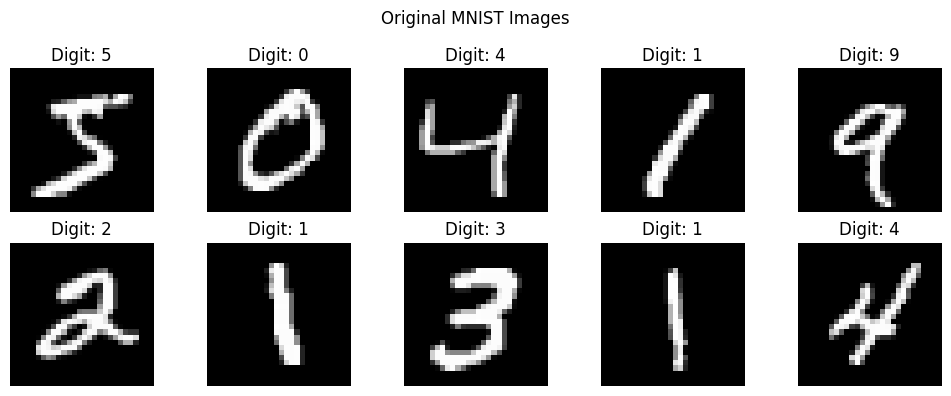


STEP 3: AUTOENCODER MODEL


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)


STEP 4: TRAINING AUTOENCODER
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.2415 - val_loss: 0.1657
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.1515 - val_loss: 0.1376
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1317 - val_loss: 0.1252
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1223 - val_loss: 0.1169
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1155 - val_loss: 0.1117
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1116 - val_loss: 0.1081
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1083 - val_loss: 0.1053
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1055 - val_loss: 0.1031
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1035 - val_loss: 0.1018
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1020 - val_loss: 0.1003


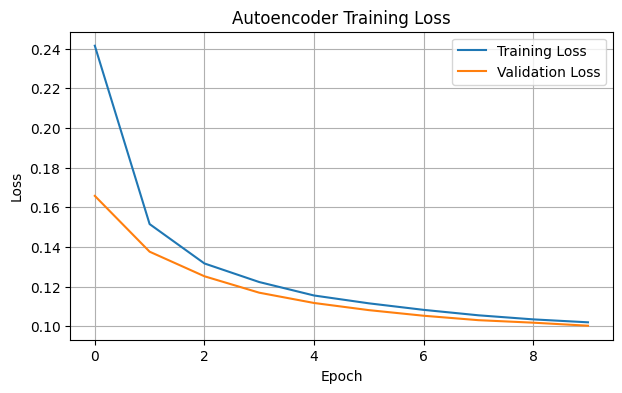

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

STEP 5: ORIGINAL VS RECONSTRUCTED IMAGES


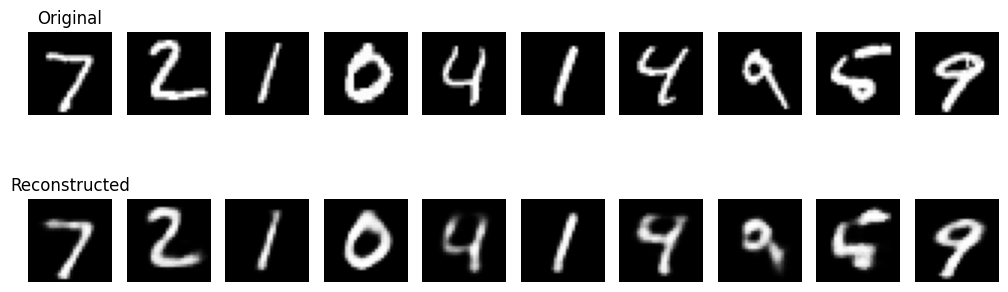

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

STEP 6: ENCODED FEATURES
Original feature size : 784
Encoded feature size  : 32

STEP 7: TRAINING DIGIT CLASSIFIER
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1341 - loss: 6.6356 - val_accuracy: 0.2796 - val_loss: 3.3125
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4226 - loss: 2.3942 - val_accuracy: 0.5595 - val_loss: 1.5885
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6122 - loss: 1.2931 - val_accuracy: 0.7026 - val_loss: 0.9332
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7251 - loss: 0.8434 - val_accuracy: 0.7805 - val_loss: 0.6770
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7838 - loss: 0.6582 - val_accuracy: 0.8196 - val_loss: 0.5585
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8162 - loss: 0.5684 - val_accuracy: 0.8418 - val_loss: 0.5000
Epoch 7/10
235/235 ━━━━━━━━━━━━━

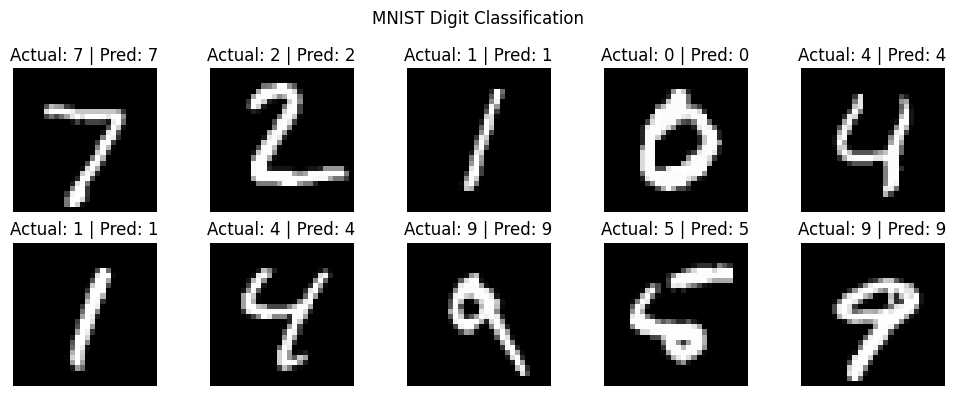


FINAL RESULT
Autoencoder successfully learned
the compressed representation of MNIST digits.
Digit classification completed successfully.


In [ ]:
# Set B - Q1. Write a python program to implement digit classification using autoencoders. (Use MNIST dataset).

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import to_categorical



(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("=" * 60)
print("STEP 1: MNIST DATASET")
print("=" * 60)

print("Training images :", x_train.shape)
print("Training labels  :", y_train.shape)
print("Testing images  :", x_test.shape)
print("Testing labels   :", y_test.shape)




x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


x_train_flat = x_train.reshape(
    x_train.shape[0], 784
)

x_test_flat = x_test.reshape(
    x_test.shape[0], 784
)

print("\n" + "=" * 60)
print("STEP 2: DATA PREPROCESSING")
print("=" * 60)

print("Image size       : 28 x 28")
print("Flattened size   : 784")
print("Pixel range      : 0 to 1")



plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_train[i],
        cmap="gray"
    )

    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.suptitle("Original MNIST Images")
plt.tight_layout()
plt.show()



input_layer = Input(shape=(784,))


encoded = Dense(
    128,
    activation="relu"
)(input_layer)

encoded = Dense(
    64,
    activation="relu"
)(encoded)


latent = Dense(
    32,
    activation="relu",
    name="latent_layer"
)(encoded)


decoded = Dense(
    64,
    activation="relu"
)(latent)

decoded = Dense(
    128,
    activation="relu"
)(decoded)

decoded = Dense(
    784,
    activation="sigmoid"
)(decoded)



autoencoder = Model(
    input_layer,
    decoded
)



autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

print("\n" + "=" * 60)
print("STEP 3: AUTOENCODER MODEL")
print("=" * 60)

autoencoder.summary()



print("\n" + "=" * 60)
print("STEP 4: TRAINING AUTOENCODER")
print("=" * 60)

history = autoencoder.fit(
    x_train_flat,
    x_train_flat,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(
        x_test_flat,
        x_test_flat
    )
)



plt.figure(figsize=(7, 4))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()



reconstructed = autoencoder.predict(
    x_test_flat
)

reconstructed = reconstructed.reshape(
    -1, 28, 28
)



print("\n" + "=" * 60)
print("STEP 5: ORIGINAL VS RECONSTRUCTED IMAGES")
print("=" * 60)

plt.figure(figsize=(10, 4))

for i in range(10):


    plt.subplot(2, 10, i + 1)

    plt.imshow(
        x_test[i],
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.title("Original")


    plt.subplot(2, 10, i + 11)

    plt.imshow(
        reconstructed[i],
        cmap="gray"
    )

    plt.axis("off")

    if i == 0:
        plt.title("Reconstructed")

plt.tight_layout()
plt.show()



encoder = Model(
    input_layer,
    latent
)


encoded_train = encoder.predict(
    x_train_flat
)

encoded_test = encoder.predict(
    x_test_flat
)

print("\n" + "=" * 60)
print("STEP 6: ENCODED FEATURES")
print("=" * 60)

print("Original feature size :", x_train_flat.shape[1])
print("Encoded feature size  :", encoded_train.shape[1])



classifier_input = Input(
    shape=(32,)
)

classifier_output = Dense(
    10,
    activation="softmax"
)(classifier_input)

classifier = Model(
    classifier_input,
    classifier_output
)

classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



print("\n" + "=" * 60)
print("STEP 7: TRAINING DIGIT CLASSIFIER")
print("=" * 60)

classifier.fit(
    encoded_train,
    y_train,
    epochs=10,
    batch_size=256,
    validation_data=(
        encoded_test,
        y_test
    )
)



loss, accuracy = classifier.evaluate(
    encoded_test,
    y_test,
    verbose=0
)

print("\n" + "=" * 60)
print("STEP 8: CLASSIFICATION RESULT")
print("=" * 60)

print("Test Loss     :", round(loss, 4))
print("Test Accuracy :", round(accuracy * 100, 2), "%")



predictions = classifier.predict(
    encoded_test[:10]
)

predicted_digits = np.argmax(
    predictions,
    axis=1
)

print("\n" + "=" * 60)
print("STEP 9: DIGIT PREDICTION")
print("=" * 60)

print("Actual Digits    :", y_test[:10])
print("Predicted Digits :", predicted_digits)



plt.figure(figsize=(10, 4))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[i],
        cmap="gray"
    )

    plt.title(
        "Actual: {} | Pred: {}".format(
            y_test[i],
            predicted_digits[i]
        )
    )

    plt.axis("off")

plt.suptitle("MNIST Digit Classification")
plt.tight_layout()
plt.show()



print("\n" + "=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Autoencoder successfully learned")
print("the compressed representation of MNIST digits.")

print("Digit classification completed successfully.")

In [ ]:
# Set B - Q2. Write a python program to implement Tic-tac-Toe using reinforcement learning.

import random
import numpy as np
import ipywidgets as widgets
from IPython.display import display



def get_state(board):
    return "".join(board)


def available_actions(board):
    return [
        i for i in range(9)
        if board[i] == " "
    ]


def check_winner(board):

    winning_positions = [
        (0, 1, 2),
        (3, 4, 5),
        (6, 7, 8),
        (0, 3, 6),
        (1, 4, 7),
        (2, 5, 8),
        (0, 4, 8),
        (2, 4, 6)
    ]

    for a, b, c in winning_positions:

        if (
            board[a] != " "
            and board[a] == board[b]
            and board[b] == board[c]
        ):
            return board[a]

    if " " not in board:
        return "Draw"

    return None



class QLearningAgent:

    def __init__(self):

        self.q_table = {}

        self.learning_rate = 0.8
        self.discount_factor = 0.95

        self.epsilon = 1.0
        self.epsilon_decay = 0.9995
        self.epsilon_min = 0.05

    def get_q_values(self, state):

        if state not in self.q_table:

            self.q_table[state] = np.zeros(9)

        return self.q_table[state]

    def choose_action(self, state, actions):

        q_values = self.get_q_values(state)

        if random.random() < self.epsilon:

            return random.choice(actions)

        return max(
            actions,
            key=lambda action: q_values[action]
        )

    def update(
        self,
        state,
        action,
        reward,
        next_state,
        next_actions
    ):

        current_q = self.get_q_values(state)[action]

        if next_actions:

            next_q = self.get_q_values(next_state)

            max_next_q = max(
                next_q[action]
                for action in next_actions
            )

        else:

            max_next_q = 0

        new_q = current_q + self.learning_rate * (
            reward
            + self.discount_factor * max_next_q
            - current_q
        )

        self.q_table[state][action] = new_q



agent = QLearningAgent()

episodes = 50000

print("=" * 60)
print("STEP 1: TRAINING REINFORCEMENT LEARNING AGENT")
print("=" * 60)

for episode in range(episodes):

    board = [" "] * 9

    state = get_state(board)

    while True:


        actions = available_actions(board)

        action = agent.choose_action(
            state,
            actions
        )

        board[action] = "X"

        result = check_winner(board)


        if result == "X":

            agent.update(
                state,
                action,
                1,
                get_state(board),
                []
            )

            break


        if result == "Draw":

            agent.update(
                state,
                action,
                0.5,
                get_state(board),
                []
            )

            break


        opponent_actions = available_actions(board)

        opponent_action = random.choice(
            opponent_actions
        )

        board[opponent_action] = "O"

        result = check_winner(board)


        if result == "O":

            agent.update(
                state,
                action,
                -1,
                get_state(board),
                []
            )

            break


        next_state = get_state(board)

        agent.update(
            state,
            action,
            0,
            next_state,
            available_actions(board)
        )

        state = next_state

    agent.epsilon = max(
        agent.epsilon_min,
        agent.epsilon * agent.epsilon_decay
    )

    if (episode + 1) % 10000 == 0:

        print(
            f"Episode {episode + 1}/{episodes}"
            f" | Epsilon = {agent.epsilon:.3f}"
        )


print("\nTraining completed!")
print("Learned States:", len(agent.q_table))



def find_winning_move(board, player):

    for position in available_actions(board):

        board[position] = player

        if check_winner(board) == player:

            board[position] = " "

            return position

        board[position] = " "

    return None


def hard_ai_move(board):

    actions = available_actions(board)


    winning_move = find_winning_move(
        board,
        "X"
    )

    if winning_move is not None:

        return winning_move



    blocking_move = find_winning_move(
        board,
        "O"
    )

    if blocking_move is not None:

        return blocking_move



    if 4 in actions:

        return 4



    state = get_state(board)

    q_values = agent.get_q_values(state)

    best_actions = sorted(
        actions,
        key=lambda x: q_values[x],
        reverse=True
    )



    corners = [0, 2, 6, 8]

    for action in best_actions:

        if action in corners:

            return action



    return best_actions[0]



board = [" "] * 9

game_over = False

player_score = 0
ai_score = 0
draw_score = 0


title = widgets.HTML(
    value="""
    <h1 style="text-align:center;">
    🎮 TIC-TAC-TOE
    </h1>

    <h3 style="text-align:center;">
    🤖 HARD REINFORCEMENT LEARNING AI
    </h3>
    """
)


score = widgets.HTML(
    value="""
    <h3 style="text-align:center;">
    You: 0 &nbsp;&nbsp;&nbsp;
    AI: 0 &nbsp;&nbsp;&nbsp;
    Draw: 0
    </h3>
    """
)


status = widgets.HTML(
    value="""
    <h3 style="text-align:center;">
    Your Turn (O)
    </h3>
    """
)



buttons = []

for i in range(9):

    button = widgets.Button(

        description=" ",

        layout=widgets.Layout(
            width="100px",
            height="100px"
        ),

        style={
            "font_weight": "bold"
        }
    )

    buttons.append(button)


row1 = widgets.HBox(buttons[0:3])

row2 = widgets.HBox(buttons[3:6])

row3 = widgets.HBox(buttons[6:9])

game_board = widgets.VBox(
    [
        row1,
        row2,
        row3
    ],

    layout=widgets.Layout(
        align_items="center"
    )
)



def update_score():

    score.value = (
        "<h3 style='text-align:center;'>"
        f"You: {player_score}"
        "&nbsp;&nbsp;&nbsp;"
        f"AI: {ai_score}"
        "&nbsp;&nbsp;&nbsp;"
        f"Draw: {draw_score}"
        "</h3>"
    )



def finish_game(result):

    global game_over
    global player_score
    global ai_score
    global draw_score

    game_over = True

    if result == "X":

        ai_score += 1

        status.value = """
        <h2 style="text-align:center;">
        🤖 AI WINS!
        </h2>
        """

    elif result == "O":

        player_score += 1

        status.value = """
        <h2 style="text-align:center;">
        🎉 YOU WIN!
        </h2>
        """

    else:

        draw_score += 1

        status.value = """
        <h2 style="text-align:center;">
        🤝 DRAW!
        </h2>
        """

    update_score()



def ai_move():

    global game_over

    if game_over:

        return

    actions = available_actions(board)

    if not actions:

        return


    action = hard_ai_move(board)

    board[action] = "X"

    buttons[action].description = "X"

    buttons[action].disabled = True

    result = check_winner(board)

    if result:

        finish_game(result)

    else:

        status.value = """
        <h3 style="text-align:center;">
        Your Turn (O)
        </h3>
        """



def player_move(button, position):

    global game_over

    if game_over:

        return

    if board[position] != " ":

        return


    board[position] = "O"

    button.description = "O"

    button.disabled = True

    result = check_winner(board)

    if result:

        finish_game(result)

        return

    status.value = """
    <h3 style="text-align:center;">
    🤖 AI is thinking...
    </h3>
    """


    ai_move()



for i in range(9):

    buttons[i].on_click(
        lambda button, i=i:
        player_move(button, i)
    )



def new_game(button=None):

    global board
    global game_over

    board = [" "] * 9

    game_over = False

    status.value = """
    <h3 style="text-align:center;">
    Your Turn (O)
    </h3>
    """

    for button in buttons:

        button.description = " "

        button.disabled = False


new_game_button = widgets.Button(

    description="🔄 NEW GAME",

    button_style="primary",

    layout=widgets.Layout(
        width="180px",
        height="45px"
    )
)

new_game_button.on_click(new_game)



instructions = widgets.HTML(
    value="""
    <div style="text-align:center; font-size:16px;">
    <b>You = O</b>
    &nbsp;&nbsp;&nbsp;|&nbsp;&nbsp;&nbsp;
    <b>AI = X</b>
    <br><br>
    ⚠️ The AI uses Reinforcement Learning.
    <br>
    The AI will try to win and block your winning moves.
    </div>
    """
)



display(
    title,
    score,
    status,
    game_board,
    new_game_button,
    instructions
)

STEP 1: TRAINING REINFORCEMENT LEARNING AGENT
Episode 10000/50000 | Epsilon = 0.050
Episode 20000/50000 | Epsilon = 0.050
Episode 30000/50000 | Epsilon = 0.050
Episode 40000/50000 | Epsilon = 0.050
Episode 50000/50000 | Epsilon = 0.050

Training completed!
Learned States: 2150


HTML(value='\n    <h1 style="text-align:center;">\n    🎮 TIC-TAC-TOE\n    </h1>\n\n    <h3 style="text-align:c…

HTML(value='\n    <h3 style="text-align:center;">\n    You: 0 &nbsp;&nbsp;&nbsp;\n    AI: 0 &nbsp;&nbsp;&nbsp;…

HTML(value='\n    <h3 style="text-align:center;">\n    Your Turn (O)\n    </h3>\n    ')

Button(button_style='primary', description='🔄 NEW GAME', layout=Layout(height='45px', width='180px'), style=Bu…

HTML(value='\n    <div style="text-align:center; font-size:16px;">\n    <b>You = O</b>\n    &nbsp;&nbsp;&nbsp;…